<div style="background: linear-gradient(135deg, #1e3a8a 0%, #3b82f6 100%); padding: 30px; border-radius: 15px; text-align: center; color: white; box-shadow: 0 10px 20px rgba(0,0,0,0.2); margin-bottom: 20px;">
    <h1 style="margin: 0; font-size: 2.5em; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 800; letter-spacing: 2px; text-transform: uppercase;">
        Disaster Tweets Analysis
    </h1>
    <hr style="border: 0; height: 1px; background-image: linear-gradient(to right, rgba(255, 255, 255, 0), rgba(255, 255, 255, 0.75), rgba(255, 255, 255, 0)); margin: 15px 0;">
    <h2 style="margin: 0; font-size: 1.5em; opacity: 0.9; font-weight: 400; font-style: italic;">
        Analyse Exploratoire et Modèles de Référence
    </h2>
</div>

In [1]:
# Installation optionnelle des d?pendances manquantes
# ? ex?cuter uniquement si ton environnement local ne contient pas encore ces packages.
# %pip install -r Eda_and_first_models/requirements.txt
# import sys
# !"{sys.executable}" -m spacy download en_core_web_sm

In [2]:
# Le notebook suppose que les d?pendances sont d?j? install?es.
# Les installations automatiques ont ?t? retir?es pour ?viter de modifier l'environnement ? chaque ex?cution.

In [3]:
from pathlib import Path
import re
import tempfile

# Donn?es
import pandas as pd
import numpy as np
from scipy.sparse import hstack

# NLP
import spacy
from gensim.models import Word2Vec

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
from wordcloud import WordCloud

# Mod?les classiques
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

# Mod?les ensemblistes
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

# Vectorisation / pipelines
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone

# ?valuation / validation
from sklearn.model_selection import cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    make_scorer,
)

# Suivi d'exp?riences
import dagshub
import mlflow
import mlflow.sklearn
import joblib

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Base" / "tweets.csv").exists():
    PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "Base" / "tweets.csv"

# Chargement du mod?le spaCy
nlp = spacy.load("en_core_web_sm")

In [4]:
# Importation des donn?es
df = pd.read_csv(DATA_PATH)
df.head(5)

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


Dans cette première étape, nous importons la base de données contenant les tweets. L’objectif est de vérifier que les données sont bien chargées et d’avoir un premier aperçu des variables disponibles.

In [5]:
df.isnull().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

On remarque que seule la variable location contient des valeurs manquantes

In [6]:
df.shape

(11370, 5)

C:\Users\Dell\AppData\Local\Temp\ipykernel_20264\2329482365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='pastel')


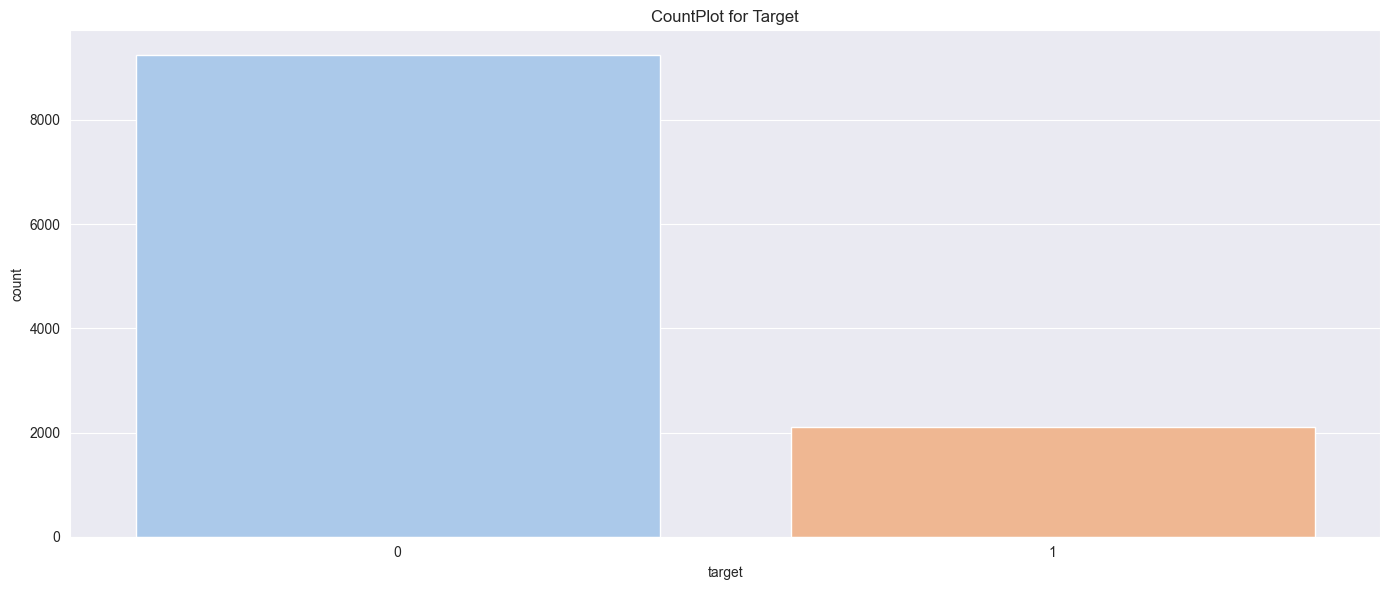

In [7]:
plt.figure(figsize=(14,6))
sns.set_style('darkgrid')
sns.countplot(data=df, x='target', palette='pastel')
plt.title('CountPlot for Target')
plt.tight_layout()
plt.show()

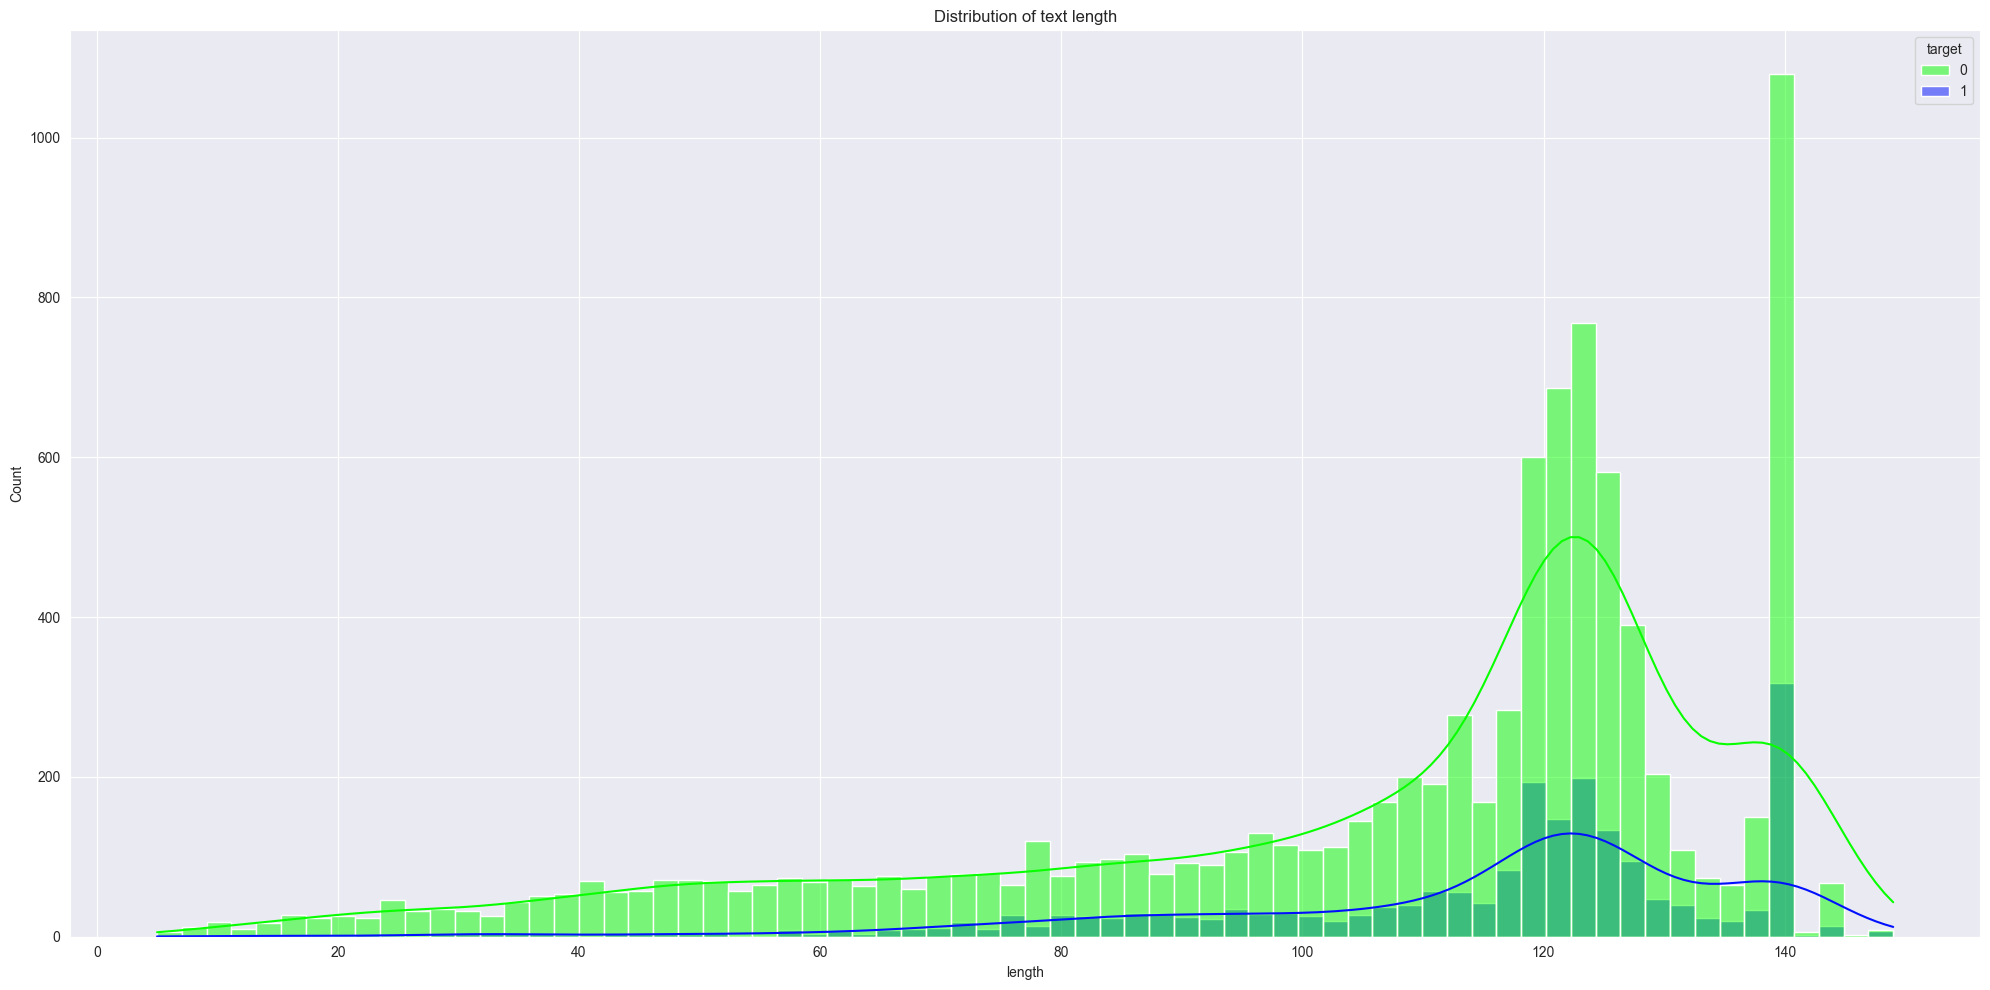

In [8]:
df['length'] = df['text'].apply(len)
plt.figure(figsize=(20,10))
sns.histplot(data=df, x='length', hue='target', palette='hsv', kde=True, bins=70)
plt.title('Distribution of text length')
plt.tight_layout()
plt.show()

In [9]:
def avgwordlen(strlist):
    sum=[]
    for i in strlist:
        sum.append(len(i))
    return sum

avgword_len_dis = df[df['target']==1]['text'].str.split().apply(avgwordlen).map(lambda x: np.mean(x))

avgword_len_non_dis = df[df['target']==0]['text'].str.split().apply(avgwordlen).map(lambda x: np.mean(x))
group_labels = ['Disaster', 'Non-Disaster']
colors = ['rgb(0, 0, 100)', 'rgb(0, 200, 200)']

fig = ff.create_distplot([avgword_len_dis, avgword_len_non_dis], group_labels, bin_size=.2, colors=colors,)

fig.update_layout(title_text="longueur moyenne de texte dans un tweets",title_x=0.5,xaxis_title="Text",yaxis_title="Density").show()


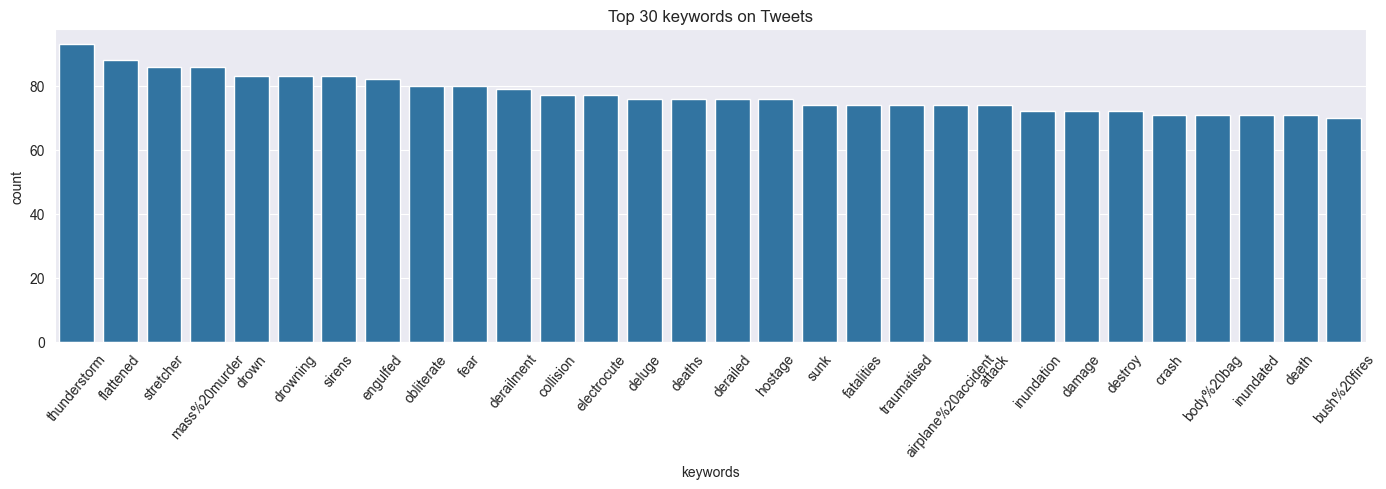

In [10]:
# Grouping by Keywords to see the count of keywords
keyword = df.groupby('keyword')['target'].count()
df_key = pd.DataFrame({'keywords':keyword.index,'count':keyword.values}).sort_values(by='count',ascending=False)

# Top 30 keywords in the Tweets.
plt.figure(figsize=(14,5))
sns.barplot(data=df_key.head(30),x='keywords',y='count')
plt.xticks(rotation = 50)
plt.title('Top 30 keywords on Tweets')
plt.tight_layout()
plt.show()

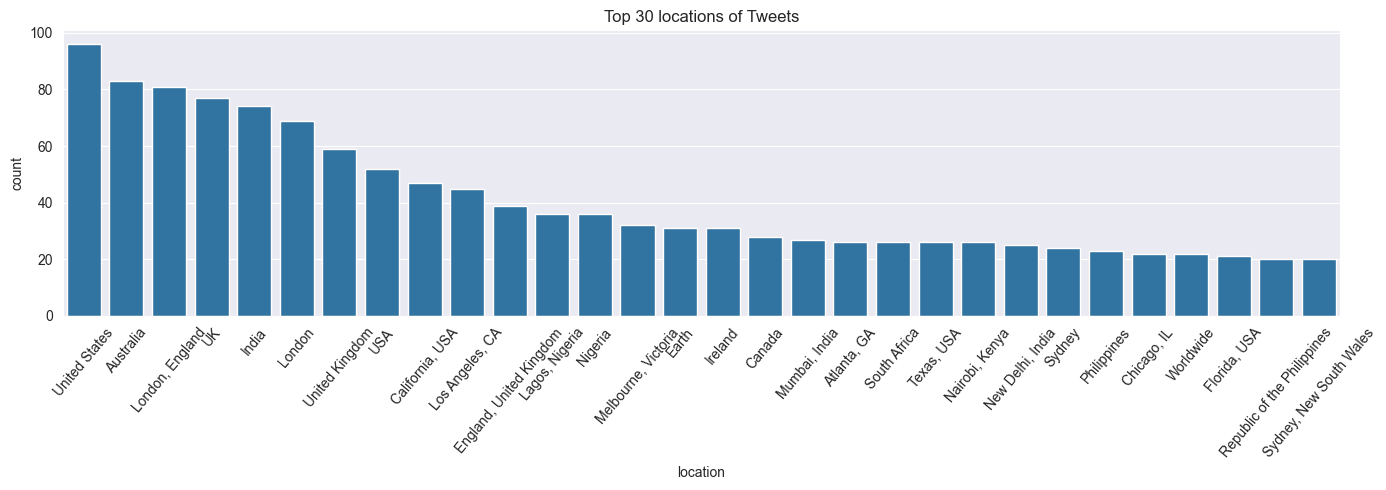

In [11]:
# Grouping by Location to find the count of each location
location = df.groupby('location')['target'].count()
df_loc = pd.DataFrame({'location':location.index,'count':location.values}).sort_values(by='count',ascending=False)

# Top 30 Location in the tweets
plt.figure(figsize=(14,5))
sns.barplot(data=df_loc.head(30),x='location',y='count')
plt.xticks(rotation = 50)
plt.title('Top 30 locations of Tweets')
plt.tight_layout()
plt.show()

# Fetaure Enginering

Tout d’abord, nous convertissons tous les mots en minuscules.
Ensuite, nous supprimons la ponctuation, les caractères spéciaux, les espaces superflus, supprimer les émoticônes,  supprimer les symboles et pictogrammes, supprimer les drapeaux,...

**Text_Cleaning**

In [12]:
def cleaning_simple(data):
    text = str(data)  # convertir en texte pour éviter les erreurs avec les valeurs manquantes

    text = re.sub(r'https?://\S+|www\.\S+|http?://\S+', ' ', text)  # supprimer les URLs

    text = re.sub(r'<.*?>', ' ', text)  # supprimer les balises HTML

    text = re.sub("["
                  u"\U0001F600-\U0001F64F"
                  u"\U0001F300-\U0001F5FF"
                  u"\U0001F680-\U0001F6FF"
                  u"\U0001F1E0-\U0001F1FF"
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", ' ', text)  # supprimer les émojis et symboles

    text = re.sub(r'@\S+', ' ', text)  # supprimer les mentions @user

    text = re.sub(r'#', '', text)  # supprimer le symbole # mais garder le mot

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # garder uniquement les lettres et les espaces

    text = text.lower()  # convertir en minuscules

    text = re.sub(r'\s+', ' ', text).strip()  # supprimer les espaces multiples

    return text

In [13]:
df["text_clean"] = df["text"].apply(cleaning_simple)
df["keyword_clean"] = df["keyword"].fillna("").apply(cleaning_simple)

Dans cette étape, nous nettoyons les variables `text` et `keyword`.  
L’objectif est uniquement de retirer les éléments bruités comme les URLs, les balises HTML, les mentions, les émojis, les caractères spéciaux et les espaces multiples.  
Les textes sont également convertis en minuscules afin d’uniformiser l’écriture.

**Tokenisation des tweets**

La tokenisation consiste à découper un texte en petites unités appelées *tokens*, généralement des mots.

Cette étape permet de transformer une phrase complète en une liste de mots individuels afin de faciliter les traitements de NLP. La tokenisation constitue souvent la première étape d’un pipeline de prétraitement textuel.

In [14]:
# Chargement de spaCy
nlp = spacy.load("en_core_web_sm")

In [15]:
# Application de la tokenisation (en mots) sur la variable texte
df["tokens"] = df["text_clean"].apply(
    lambda texte: [token.text for token in nlp(str(texte))]
)

In [16]:
# Affichage des résultats de la tekenisation
df[["text_clean", "tokens"]].head()

,text_clean,tokens
0,communal violence in bhainsa telangana stones ...,"[communal, violence, in, bhainsa, telangana, s..."
1,telangana section has been imposed in bhainsa ...,"[telangana, section, has, been, imposed, in, b..."
2,arsonist sets cars ablaze at dealership,"[arsonist, sets, cars, ablaze, at, dealership]"
3,arsonist sets cars ablaze at dealership,"[arsonist, sets, cars, ablaze, at, dealership]"
4,lord jesus your love brings freedom and pardon...,"[lord, jesus, your, love, brings, freedom, and..."


Chaque tweet est désormais représenté sous forme d’une liste de mots et symboles. Cette représentation permet de préparer les étapes suivantes du pipeline de prétraitement, comme la suppression des mots vides, le nettoyage ou la lemmatisation.

**POS Tagging (Part-Of-Speech Tagging)**

Le POS Tagging consiste à attribuer à chaque mot sa catégorie grammaticale dans une phrase.

Chaque token peut ainsi être identifié comme :
- un nom (NOUN),
- un verbe (VERB),
- un adjectif (ADJ),
- un adverbe (ADV),
- etc.
Cette étape permet de mieux comprendre la structure grammaticale des tweets et facilite certaines opérations avancées de NLP, notamment la lemmatisation et l’analyse sémantique.

In [17]:
# POS tagging sur les tokens
df["pos_tags"] = df["tokens"].apply(
    lambda tokens: [(token.text, token.pos_) for token in nlp(" ".join(tokens))]
)

# Affichage des résultats
df[["tokens", "pos_tags"]].head()

,tokens,pos_tags
0,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),..."
1,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A..."
2,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),..."
3,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),..."
4,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ..."


Après la tokenisation, nous appliquons le POS tagging afin d’associer chaque token à sa catégorie grammaticale. Pour cela, les tokens sont temporairement recombinés en texte afin que spaCy puisse attribuer les étiquettes grammaticales à chaque mot.

**Suppression des stopwords (+ Suppression des tokens de mois de trois lettres)**

Les stopwords sont des mots très fréquents dans une langue qui apportent généralement peu d’information pour la classification des textes. Il s’agit par exemple de mots comme : *the*, *is*, *and*, *in*, etc.

L’objectif de cette étape est de conserver uniquement les mots les plus informatifs afin de réduire le bruit dans les données textuelles.

In [18]:
# Filtrage des tokens selon leur catégorie grammaticale
df["tokens_pos_utiles"] = df["pos_tags"].apply(
    lambda pos_tags: [
        mot for mot, pos in pos_tags
        if pos in ["NOUN", "VERB", "ADJ", "ADV", "PROPN"]
    ]
)

# Affichage des résultats
df[["tokens", "pos_tags", "tokens_pos_utiles"]].head()


,tokens,pos_tags,tokens_pos_utiles
0,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A...","[telangana, section, imposed, bhainsa, january..."
2,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]"
4,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ...","[lord, jesus, love, brings, freedom, pardon, f..."


In [19]:
# Supprimer ces textes

# Sélection des tweets ne contenant aucun token grammatical utile
tweets_sans_pos_utiles = df[
    df["tokens_pos_utiles"].apply(len) == 0
]

# Affichage des textes concernés
tweets_sans_pos_utiles[
    ["text_clean", "tokens", "pos_tags", "tokens_pos_utiles"]
]

,text_clean,tokens,pos_tags,tokens_pos_utiles
337,,[],[],[]
688,,[],[],[]
1500,i will,"[i, will]","[(i, PRON), (will, AUX)]",[]
4449,,[],[],[]
6204,hello,[hello],"[(hello, INTJ)]",[]
8029,,[],[],[]
8030,,[],[],[]
10862,,[],[],[]


Après l’application du POS tagging, un filtrage grammatical a été effectué afin de conserver uniquement les catégories de mots considérées comme les plus informatives pour l’analyse textuelle, notamment :

les noms (NOUN),
les verbes (VERB),
les adjectifs (ADJ),
les adverbes (ADV),
ainsi que les noms propres (PROPN).

L’objectif de cette étape est de réduire le bruit linguistique en supprimant les mots moins pertinents sur le plan sémantique, tout en conservant les termes les plus susceptibles de porter une information utile pour la classification des tweets.

In [20]:
# Nombre de tweets contenant au moins un token grammatical utile
nb_tweets_utiles = (df["tokens_pos_utiles"].apply(len) > 0).sum()

# Nombre total de tweets
nb_total = len(df)

# Pourcentage
pourcentage = round((nb_tweets_utiles / nb_total) * 100, 2)

print("Nombre de tweets contenant des tokens utiles :", nb_tweets_utiles)
print("Nombre total de tweets :", nb_total)
print("Pourcentage :", pourcentage, "%")

Nombre de tweets contenant des tokens utiles : 11362
Nombre total de tweets : 11370
Pourcentage : 99.93 %


Les résultats obtenus montrent que 11 362 tweets sur 11 370, soit 99,93 % des tweets, contiennent au moins un token grammatical jugé utile après le filtrage. Cela signifie que presque tous les tweets de la base possèdent des mots porteurs de sens appartenant aux catégories grammaticales retenues.

Ce résultat est particulièrement intéressant, car il montre que :

les tweets contiennent généralement une information textuelle exploitable ;
le filtrage grammatical ne provoque pas une perte importante d’information ;
les catégories grammaticales sélectionnées couvrent efficacement le contenu des tweets.

Par ailleurs, le très faible nombre de tweets ne contenant aucun token utile après filtrage suggère que la majorité des messages restent suffisamment riches sur le plan lexical pour être exploités dans les étapes suivantes du pipeline NLP.

**Suppression des tweets ne contenant aucun mot ayant une nature grammaticale**

In [21]:
# Suppression des tweets ne contenant aucun token grammatical utile
df = df[
    df["tokens_pos_utiles"].apply(len) > 0
].reset_index(drop=True)

# Vérification
df.shape

(11362, 11)

In [22]:
# Suppression des stopwords sur la variable tokens_pos_utiles
df["tokens_pos_sans_stopwords"] = df["tokens_pos_utiles"].apply(
    lambda tokens: [
        mot for mot in tokens
        if not nlp.vocab[mot].is_stop and len(mot) > 2
    ]
)

# Affichage des résultats
df[["tokens_pos_utiles", "tokens_pos_sans_stopwords"]].head()

,tokens_pos_utiles,tokens_pos_sans_stopwords
0,"[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, imposed, bhainsa, january...","[telangana, section, imposed, bhainsa, january..."
2,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]"
4,"[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, brings, freedom, pardon, f..."


Après le filtrage grammatical, les stopwords ont été supprimés afin d’éliminer les mots très fréquents et peu informatifs comme the, is, and ou in. Cette étape permet de réduire le bruit dans les données textuelles et de conserver principalement les mots les plus utiles pour la classification des tweets. Les textes obtenus sont ainsi plus légers, plus pertinents et mieux adaptés aux méthodes de vectorisation (TF-IDF, ...) ainsi qu’aux modèles de machine learning.

**Lemmatisation**

In [23]:
# Lemmatisation après suppression des stopwords
df["tokens_lemmatized"] = df["tokens_pos_sans_stopwords"].apply(
    lambda tokens: [
        token.lemma_ for token in nlp(" ".join(tokens))
    ]
)
# Affichage des résultats
df[["tokens_pos_sans_stopwords", "tokens_lemmatized"]].head()

,tokens_pos_sans_stopwords,tokens_lemmatized
0,"[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,"[telangana, section, imposed, bhainsa, january...","[telangana, section, impose, bhainsa, january,..."
2,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
3,"[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
4,"[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, bring, freedom, pardon, fi..."


La lemmatisation consiste à ramener chaque mot à sa forme de base appelée lemme. Par exemple, *running*, *runs* et ran seront ramenés à *run*. Cette étape permet de regrouper différentes formes d’un même mot afin de réduire la taille du vocabulaire et d’améliorer la qualité de la représentation textuelle avant la vectorisation et la modélisation.

In [24]:
df.head(10)

,id,keyword,location,text,target,length,text_clean,keyword_clean,tokens,pos_tags,tokens_pos_utiles,tokens_pos_sans_stopwords,tokens_lemmatized
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1,125,communal violence in bhainsa telangana stones ...,ablaze,"[communal, violence, in, bhainsa, telangana, s...","[(communal, ADJ), (violence, NOUN), (in, ADP),...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone...","[communal, violence, bhainsa, telangana, stone..."
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1,131,telangana section has been imposed in bhainsa ...,ablaze,"[telangana, section, has, been, imposed, in, b...","[(telangana, PROPN), (section, PROPN), (has, A...","[telangana, section, imposed, bhainsa, january...","[telangana, section, imposed, bhainsa, january...","[telangana, section, impose, bhainsa, january,..."
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,63,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,87,arsonist sets cars ablaze at dealership,ablaze,"[arsonist, sets, cars, ablaze, at, dealership]","[(arsonist, NOUN), (sets, VERB), (cars, NOUN),...","[arsonist, sets, cars, ablaze, dealership]","[arsonist, sets, cars, ablaze, dealership]","[arsonist, set, car, ablaze, dealership]"
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0,140,lord jesus your love brings freedom and pardon...,ablaze,"[lord, jesus, your, love, brings, freedom, and...","[(lord, PROPN), (jesus, PROPN), (your, PRON), ...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, brings, freedom, pardon, f...","[lord, jesus, love, bring, freedom, pardon, fi..."
5,5,ablaze,OC,"If this child was Chinese, this tweet would ha...",0,122,if this child was chinese this tweet would hav...,ablaze,"[if, this, child, was, chinese, this, tweet, w...","[(if, SCONJ), (this, DET), (child, NOUN), (was...","[child, chinese, tweet, gone, viral, social, m...","[child, chinese, tweet, gone, viral, social, m...","[child, chinese, tweet, go, viral, social, med..."
6,6,ablaze,"London, England",Several houses have been set ablaze in Ngemsib...,1,139,several houses have been set ablaze in ngemsib...,ablaze,"[several, houses, have, been, set, ablaze, in,...","[(several, ADJ), (houses, NOUN), (have, AUX), ...","[several, houses, set, ablaze, ngemsibaa, vill...","[houses, set, ablaze, ngemsibaa, village, oku,...","[house, set, ablaze, ngemsibaa, village, oku, ..."
7,7,ablaze,Bharat,Asansol: A BJP office in Salanpur village was ...,1,131,asansol a bjp office in salanpur village was s...,ablaze,"[asansol, a, bjp, office, in, salanpur, villag...","[(asansol, PROPN), (a, DET), (bjp, PROPN), (of...","[asansol, bjp, office, salanpur, village, set,...","[asansol, bjp, office, salanpur, village, set,...","[asansol, bjp, office, salanpur, village, set,..."
8,8,ablaze,"Accra, Ghana","National Security Minister, Kan Dapaah's side ...",0,135,national security minister kan dapaah s side c...,ablaze,"[national, security, minister, kan, dapaah, s,...","[(national, ADJ), (security, PROPN), (minister...","[national, security, minister, kan, dapaah, si...","[national, security, minister, kan, dapaah, ch...","[national, security, minister, kan, dapaah, ch..."
9,9,ablaze,Searching,This creature who’s soul is no longer clarent ...,0,127,this creature who s soul is no longer clarent ...,ablaze,"[this, creature, who, s, soul, is, no, longer,...","[(this, DET), (creature, NOUN), (who, PRON), (...","[creature, s, soul, longer, clarent, blue, abl...","[creature, soul, longer, clarent, blue, ablaze...","[creature, soul, long, clarent, blue

# Analyse de la variable Keyword

**Lemmatisation**

In [25]:
df["keyword_lemma"] = df["keyword_clean"].apply(
    lambda texte: " ".join(
        [token.lemma_ for token in nlp(texte)]
    )
)

In [26]:
df["keyword_lemma"].unique()

array(['ablaze', 'accident', 'aftershock', 'airplane accident',
       'ambulance', 'annihilate', 'annihilation', 'apocalypse',
       'armageddon', 'army', 'arson', 'arsonist', 'attack', 'avalanche',
       'battle', 'bioterror', 'bioterrorism', 'blaze', 'bleed', 'blow up',
       'blight', 'blizzard', 'blood', 'bloody', 'body bag',
       'body bagging', 'bomb', 'bombing', 'bridge collapse',
       'building burn', 'building on fire', 'burn', 'bush fire',
       'casualty', 'catastrophe', 'catastrophic', 'chemical emergency',
       'cliff fall', 'collapse', 'collide', 'collision', 'crash', 'crush',
       'curfew', 'cyclone', 'damage', 'danger', 'dead', 'death', 'debris',
       'deluge', 'demolish', 'demolition', 'derail', 'derailment',
       'desolate', 'desolation', 'destroy', 'destruction', 'detonate',
       'devastate', 'devastation', 'disaster', 'displace', 'drought',
       'drown', 'dust storm', 'earthquake', 'electrocute', 'emergency',
       'emergency plan', 'emergency 

La variable ***keyword*** représente un mot-clé associé au tweet, censé indiquer son thème principal (par exemple : fire, earthquake, flood). Cependant, cette variable apparaît largement redondante avec le contenu de la variable textuelle principale (text). En effet, les mots présents dans keyword se retrouvent très souvent directement dans le texte du tweet. Ainsi, l’utilisation conjointe de keyword et du texte brut peut entraîner une duplication de l’information, sans apport significatif pour le modèle. Dans ce contexte, il est donc préférable de ne pas inclure cette variable afin d’éviter tout biais ou sur-apprentissage

# Analyse de la variable location

In [27]:
# Détermination des tweets ayant un mots qui se trouvent dans location et dans texte en même temps
def location_in_text(row):
    if pd.isna(row["location"]):
        return False

    loc_words = str(row["location"]).lower().split()
    text = str(row["text"]).lower()

    return any(word in text for word in loc_words)

df["loc_in_text"] = df.apply(location_in_text, axis=1)
ids = df[df["loc_in_text"] == True]["id"]
ids

5            5
23          23
34          34
66          66
69          69
         ...  
11263    11271
11287    11295
11305    11313
11324    11332
11357    11365
Name: id, Length: 844, dtype: int64

In [28]:
# Répartition selon les tweets catastrophiques et non
df.loc[df["loc_in_text"], "target"].value_counts()

target
0    650
1    194
Name: count, dtype: int64

Concernant la variable **location**, une analyse exploratoire montre que certains mots issus de cette colonne apparaissent également dans le **texte** des tweets. Il apparaît que 509 tweets contiennent à la fois une information de localisation et des mots similaires dans leur contenu. Toutefois, cette information reste peu discriminante : comme l’indiquent les résultats, parmi les tweets contenant une localisation, on observe à la fois des tweets catastrophiques (122) et non catastrophiques (387). Cela montre clairement que la présence d’une localisation n’est pas un indicateur fiable de la nature du **tweet**.

Par conséquent, la transformation de cette variable en une variable binaire (présence ou absence de localisation) ne semble pas pertinente. En effet, cette binarisation ne permet pas de distinguer efficacement les classes et risque d’introduire du bruit plutôt que de l’information utile dans le modèle.

In [29]:
# Sélection des variables utiles pour la modélisation

# Variables explicatives
# Construction du texte final à partir des tokens lemmatisés
df["text_final"] = df["tokens_lemmatized"].apply(
    lambda tokens: " ".join(tokens)
)
X_text = df["text_final"]

X_keyword = df["keyword_lemma"]

# Variable cible
y = df["target"]

# Base finale
df_final = df[["text_final", "keyword_lemma", "target"]]

# Aperçu
df_final.head()


,text_final,keyword_lemma,target
0,communal violence bhainsa telangana stones pel...,ablaze,1
1,telangana section impose bhainsa january clash...,ablaze,1
2,arsonist set car ablaze dealership,ablaze,1
3,arsonist set car ablaze dealership,ablaze,1
4,lord jesus love bring freedom pardon fill holy...,ablaze,0


**Visualisation des nuages de mots (selon la nature du tweet)**

In [30]:
disaster = ' '.join(df[df_final['target']==1]['text_final'])
non_disaster =''.join(df[df_final['target']==0]['text_final'])

**Tweets catastrophiques**

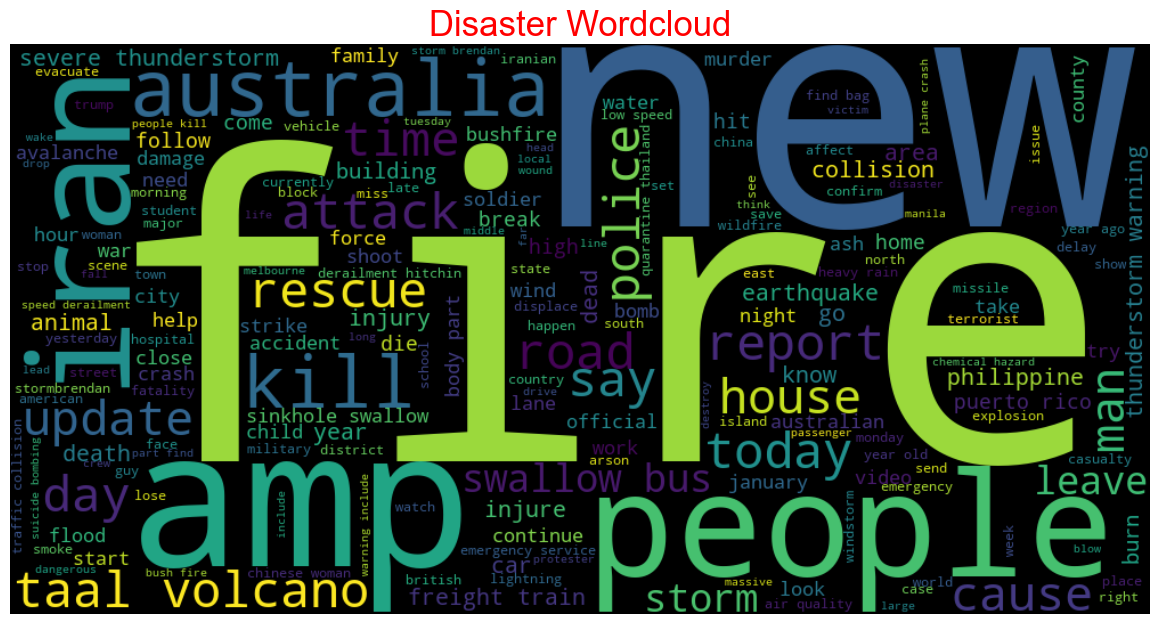

In [31]:
plt.figure(figsize=(14,6))
wordcloud = WordCloud(width=1000,height=500).generate(disaster)
plt.imshow(wordcloud,interpolation='bilinear',cmap='magma')
plt.axis('off')
plt.tight_layout()
plt.title('Disaster Wordcloud',fontsize= 25,color='Red')
plt.show()

**Tweets non catastrophiques**

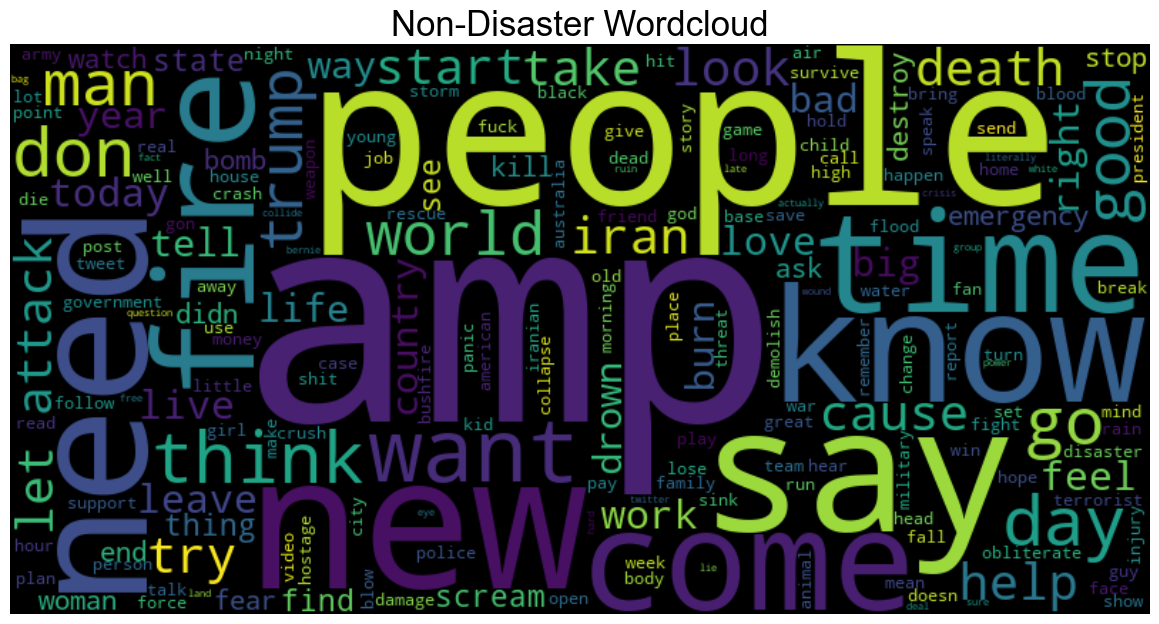

In [32]:
plt.figure(figsize=(14,6),frameon=True)
wordcloud = WordCloud(width=800,height=400).generate(non_disaster)
plt.imshow(wordcloud,interpolation='bilinear',cmap='Dark2')
plt.axis('off')
plt.tight_layout()
plt.title('Non-Disaster Wordcloud',fontsize= 25,color='Black')
plt.show()

**Représentation vectorielle des tweets**

Après les différentes étapes de prétraitement (nettoyage, tokenisation, filtrage grammatical, suppression des stopwords et lemmatisation), les données textuelles doivent être transformées en représentations numériques afin de pouvoir être exploitées par les modèles de machine learning.

Plusieurs techniques de représentation vectorielle existent en traitement automatique du langage naturel (NLP), parmi lesquelles :

**One-Hot Encoding** ;
**Bag of Words (BoW)** ;
**TF-IDF (Term Frequency – Inverse Document Frequency)** ;
**Word Embeddings comme Word2Vec ou GloVe** ;
ainsi que les représentations contextuelles basées sur les Transformers.

Dans ce projet, deux approches seront retenues selon le type de modèle (hors deep learning) utilisé.

Pour les modèles de base (baseline models), notamment :

**la régression logistique**,
**le SVM**,
**et Naive Bayes**,

la méthode **TF-IDF** sera utilisée. Cette représentation est particulièrement adaptée aux modèles classiques de classification textuelle, car elle permet de mettre en valeur les mots les plus informatifs tout en restant simple, rapide et efficace sur des données textuelles de grande dimension.

En revanche, pour les modèles ensemblistes comme :

**Random Forest**,
**Gradient Boosting**,
et **XGBoost**,

une représentation plus dense et plus compacte sera privilégiée à l’aide des **Word Embeddings**. Contrairement à **TF-IDF**, ces représentations permettent de capturer certaines relations sémantiques entre les mots et sont généralement mieux adaptées aux modèles basés sur les arbres de décision.

# TF-IDF

In [33]:
# Variables explicatives
X_text = df_final["text_final"].astype(str)
X_keyword = df_final["keyword_lemma"].astype(str)

# TF-IDF sur le texte principal
tfidf_text = TfidfVectorizer()
X_text_tfidf = tfidf_text.fit_transform(X_text)

# TF-IDF sur keyword
tfidf_keyword = TfidfVectorizer()
X_keyword_tfidf = tfidf_keyword.fit_transform(X_keyword)

# Combinaison numérique des deux matrices
X_tfidf = hstack([X_text_tfidf, X_keyword_tfidf])

In [34]:
print("Dimensions texte TF-IDF :", X_text_tfidf.shape)
print("Dimensions keyword TF-IDF :", X_keyword_tfidf.shape)
print("Dimensions finales :", X_tfidf.shape)

Dimensions texte TF-IDF : (11362, 16873)
Dimensions keyword TF-IDF : (11362, 190)
Dimensions finales : (11362, 17063)


In [35]:
# Affichage de la matrice TF-IDF
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 105002 stored elements and shape (11362, 17063)>
  Coords	Values
  (0, 2924)	0.33323474932418296
  (0, 16119)	0.26119210441830837
  (0, 1498)	0.29129303559764913
  (0, 14882)	0.28651468315699474
  (0, 14303)	0.34175369913539344
  (0, 11153)	0.33323474932418296
  (0, 9944)	0.250209267933149
  (0, 6952)	0.4225503424682693
  (0, 15999)	0.24688743519716635
  (0, 13381)	0.22163722992672505
  (0, 34)	0.27334971030301297
  (0, 16873)	1.0
  (1, 1498)	0.32406059382269375
  (1, 14882)	0.318744724439701
  (1, 13247)	0.35075856135244415
  (1, 7238)	0.35642984304902103
  (1, 7766)	0.513706524798234
  (1, 2702)	0.3457561363708998
  (1, 4883)	0.2905736084144099
  (1, 6323)	0.2746598067241991
  (1, 16873)	1.0
  (2, 13381)	0.3606255811716649
  (2, 34)	0.4447668750133746
  (2, 822)	0.4530615412268735
  (2, 2247)	0.37076018978375613
  :	:
  (11359, 3502)	0.27664965808802117
  (11359, 3087)	0.27664965808802117
  (11359, 943)	0.20030635834730343

Plus lisible

In [36]:
# Conversion des premières lignes en DataFrame
tfidf_df = pd.DataFrame(
    X_tfidf[:5].toarray()
)

tfidf_df.head()

,0,1,2,3,4,5,6,7,8,9,...,17053,17054,17055,17056,17057,17058,17059,17060,17061,17062
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Les modèles classiques 

In [37]:
X = df_final[["text_final", "keyword_lemma"]].copy()
y = df_final["target"].copy()

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Configuration MLflow / DagsHub
</h3>


In [38]:

# Les runs seront visibles dans le repo DagsHub du projet.
dagshub.init(repo_owner="Oscar-AS", repo_name="disaster-tweets-project", mlflow=True)
mlflow.set_experiment("disaster-tweets")

Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

<Experiment: artifact_location='mlflow-artifacts:/cc914a398be4408393ce563405f5a2a0', creation_time=1778238616831, experiment_id='6', last_update_time=1778238616831, lifecycle_stage='active', name='disaster-tweets', tags={}, trace_location=None, workspace='default'>

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Choix de la métrique : F2-Score
</h3>

Dans le contexte de la détection de tweets liés à des catastrophes, le coût d'un **faux négatif** (ne pas détecter une catastrophe réelle) est bien plus élevé que celui d'un **faux positif** (signaler une catastrophe là où il n'y en a pas). 

C'est pourquoi nous privilégions le **F2-score** comme métrique principale. Contrairement au F1-score qui équilibre précision et rappel, le F2-score accorde deux fois plus d'importance au **rappel (recall)**. L'objectif est de maximiser la capacité du modèle à identifier le plus grand nombre possible de situations d'urgence, quitte à accepter quelques fausses alertes.

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Fonctions
</h3>


In [49]:


f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)


def compute_classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        # Le F2-score donne plus de poids au rappel pour minimiser les faux négatifs (catastrophes non détectées)
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }


def compute_detailed_metrics(y_true, y_pred):
    metrics = compute_classification_metrics(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # M?triques par classe pour comparer finement les mod?les dans MLflow.
    for class_label in ["0", "1"]:
        if class_label in report:
            prefix = f"class_{class_label}"
            metrics[f"{prefix}_precision"] = report[class_label]["precision"]
            metrics[f"{prefix}_recall"] = report[class_label]["recall"]
            metrics[f"{prefix}_f1"] = report[class_label]["f1-score"]
            metrics[f"{prefix}_support"] = report[class_label]["support"]

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics.update({"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})

    return metrics, report, cm


def sanitize_mlflow_params(params):
    clean_params = {}
    for key, value in params.items():
        if isinstance(value, (str, int, float, bool, type(None))):
            clean_params[key] = value
        else:
            value_as_text = str(value)
            if len(value_as_text) <= 250:
                clean_params[key] = value_as_text
    return clean_params


def log_confusion_matrix_figure(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non disaster", "Disaster"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig)


def log_model_run(
    run_name,
    model,
    X_train_full,
    y_train_full,
    y_true,
    y_pred,
    params=None,
    tags=None,
    cv_folds=None,
    extra_metrics=None,
    extra_artifacts=None,
):
    metrics, report, cm = compute_detailed_metrics(y_true, y_pred)
    if extra_metrics:
        metrics.update(extra_metrics)

    fitted_model = clone(model)
    fitted_model.fit(X_train_full, y_train_full)
    params_to_log = sanitize_mlflow_params(params or fitted_model.get_params(deep=True))

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags(tags or {})
        mlflow.log_params(params_to_log)
        mlflow.log_param("n_samples", len(y_train_full))
        mlflow.log_param("positive_class", 1)
        if cv_folds is not None:
            mlflow.log_param("cv_folds", cv_folds)
        if hasattr(X_train_full, "shape"):
            mlflow.log_param("n_features", X_train_full.shape[1] if len(X_train_full.shape) > 1 else 1)

        mlflow.log_metrics(metrics)
        mlflow.log_dict(report, "classification_report.json")
        mlflow.log_dict({"confusion_matrix": cm.tolist()}, "confusion_matrix.json")
        log_confusion_matrix_figure(cm, f"Matrice de confusion - {run_name}")

        if extra_artifacts:
            for artifact_name, artifact_value in extra_artifacts.items():
                if isinstance(artifact_value, pd.DataFrame):
                    with tempfile.TemporaryDirectory() as tmp_dir:
                        artifact_path = Path(tmp_dir) / artifact_name
                        artifact_value.to_csv(artifact_path, index=False)
                        mlflow.log_artifact(str(artifact_path))
                else:
                    mlflow.log_dict(artifact_value, artifact_name)

        try:
            mlflow.sklearn.log_model(fitted_model, name="model")
        except Exception as exc:
            print(f"WARNING: impossible de logger le modele dans MLflow/DagsHub ({type(exc).__name__}): {exc}")

    return metrics, fitted_model

In [40]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
svc = SVC(kernel="linear", random_state=RANDOM_STATE)
mnb = MultinomialNB()

models = [
    ("Logistic Regression", lr),
    ("SVC", svc),
    ("MultinomialNB", mnb),
]

**Évaluation des modèles**


==================== Logistic Regression ====================


2026/05/08 11:26:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 11:26:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run baseline_tfidf_Logistic Regression at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/a626348b6e0949ff838ee5ec4da7d5fe
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      9248
           1       0.85      0.41      0.55      2114

    accuracy                           0.88     11362
   macro avg       0.86      0.69      0.74     11362
weighted avg       0.87      0.88      0.86     11362



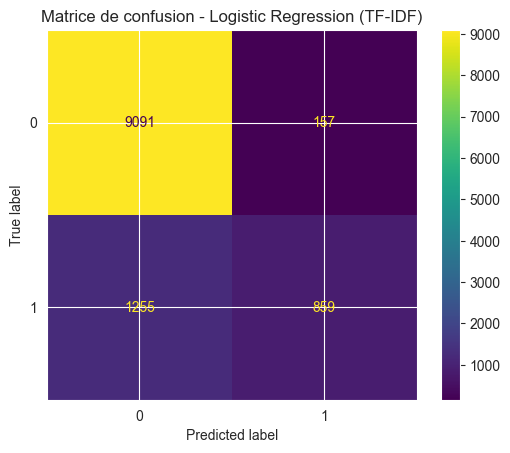


==================== SVC ====================


2026/05/08 11:28:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 11:28:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run baseline_tfidf_SVC at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/b9973320cfec4b3b8a6069e5bb0bb49e
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      9248
           1       0.80      0.53      0.64      2114

    accuracy                           0.89     11362
   macro avg       0.85      0.75      0.79     11362
weighted avg       0.88      0.89      0.88     11362



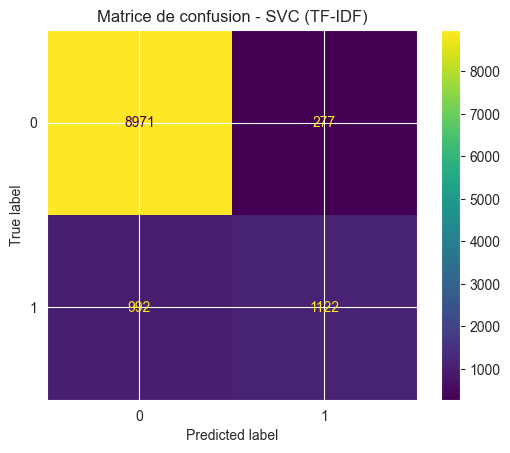


==================== MultinomialNB ====================


2026/05/08 11:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 11:29:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run baseline_tfidf_MultinomialNB at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/729f52ae953647e0a3c5fbc44ed8e79b
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      9248
           1       0.85      0.29      0.43      2114

    accuracy                           0.86     11362
   macro avg       0.85      0.64      0.68     11362
weighted avg       0.86      0.86      0.83     11362



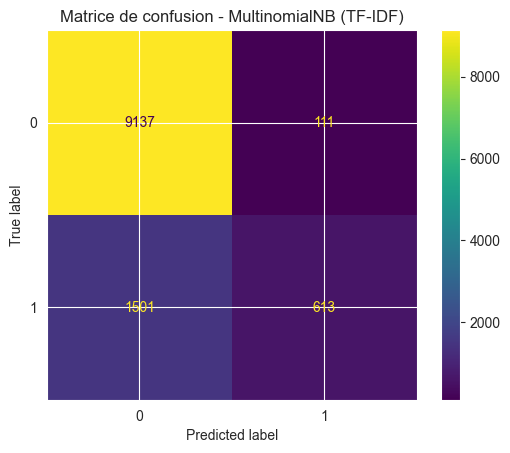

In [41]:
# Validation crois?e
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Stockage des r?sultats
resultats_tfidf = []
fitted_tfidf_models = {}

for nom, modele in models:
    print(f"\n==================== {nom} ====================")

    pred = cross_val_predict(modele, X_tfidf, y, cv=cv)

    metrics, fitted_model = log_model_run(
        run_name=f"baseline_tfidf_{nom}",
        model=modele,
        X_train_full=X_tfidf,
        y_train_full=y,
        y_true=y,
        y_pred=pred,
        params=modele.get_params(deep=True),
        tags={"model_family": "baseline", "vectorizer": "tfidf", "tracked_in_mlflow": "true"},
        cv_folds=cv.get_n_splits(),
    )
    fitted_tfidf_models[nom] = fitted_model

    print(classification_report(y, pred, zero_division=0))

    ConfusionMatrixDisplay(confusion_matrix(y, pred)).plot()
    plt.title(f"Matrice de confusion - {nom} (TF-IDF)")
    plt.show()

    resultats_tfidf.append([
        nom,
        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["f2"],
    ])

# Analyse comparative des modèles baseline

Les trois modèles testés (**Régression Logistique**, **SVM** et **Naive Bayes**) présentent des performances globalement satisfaisantes en termes d’**accuracy**, comprises entre **86 %** et **89 %**. Toutefois, une analyse plus fine des métriques révèle des différences importantes dans leur capacité à détecter les tweets de catastrophe (classe 1).

La **Régression Logistique** obtient une bonne **accuracy** globale de **88 %**, mais montre une capacité limitée à détecter les catastrophes, avec un **recall** de seulement **0.40** pour la classe 1. Cela signifie qu’une partie importante des tweets réellement catastrophiques n’est pas correctement identifiée. Son **F1-score** pour cette classe atteint **0.54**.

Le modèle **SVM** se distingue comme le plus performant parmi les modèles baseline. Il atteint la meilleure **accuracy** (**89 %**) et présente le meilleur équilibre entre **précision** et **rappel**, notamment pour la classe 1 avec un **recall** de **0.53** et un **F1-score** de **0.64**. Il est donc plus efficace pour détecter les tweets liés aux catastrophes tout en conservant de bonnes performances globales.

Le modèle **Naive Bayes** obtient une **accuracy** correcte de **86 %**, mais il reste fortement déséquilibré. Il identifie presque parfaitement les tweets non catastrophiques, avec un **recall** de **0.99** pour la classe 0, mais détecte difficilement les catastrophes, avec un **recall** limité à **0.29** et un **F1-score** de **0.43** pour la classe 1. Ce comportement montre qu’il est fortement biaisé vers la classe majoritaire.

Globalement, les résultats montrent que le modèle **SVM** associé à la représentation **TF-IDF** constitue le modèle baseline le plus performant pour cette tâche de classification des tweets de catastrophe.

**Tableau récapitulatif**

In [42]:
# Cr?ation du tableau r?capitulatif des performances
resultats_tfidf = pd.DataFrame(
    resultats_tfidf,
    columns=["Modèle", "Accuracy", "Pr?cision", "Recall", "F1-score", "F2-score"]
)

colonnes_scores = ["Accuracy", "Pr?cision", "Recall", "F1-score", "F2-score"]
resultats_tfidf[colonnes_scores] = (resultats_tfidf[colonnes_scores] * 100).round(2)

resultats_tfidf = resultats_tfidf.sort_values(by="F2-score", ascending=False).reset_index(drop=True)

resultats_tfidf

,Modèle,Accuracy,Pr?cision,Recall,F1-score,F2-score
0,SVC,88.83,80.20,53.07,63.88,56.93
1,Logistic Regression,87.57,84.55,40.63,54.89,45.34
2,MultinomialNB,85.81,84.67,29.00,43.20,33.39


# Les méthodes d'Ensemble

**Transformation vectorielle (Word Embeddings: Word2Vec)**

In [46]:
class Word2VecVectorizer(BaseEstimator, TransformerMixin):

    def __init__(self, vector_size=100, window=5, min_count=1, workers=1):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers

    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=["text_final", "keyword_lemma"])

        sentences_text = [str(text).split() for text in X["text_final"]]
        sentences_keyword = [str(text).split() for text in X["keyword_lemma"]]

        all_sentences = sentences_text + sentences_keyword

        self.w2v_model_ = Word2Vec(
            sentences=all_sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            seed=RANDOM_STATE
        )

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=["text_final", "keyword_lemma"])

        vectors = []

        for text, keyword in zip(X["text_final"], X["keyword_lemma"]):
            text_tokens = str(text).split()
            keyword_tokens = str(keyword).split()

            text_vectors = [
                self.w2v_model_.wv[word]
                for word in text_tokens
                if word in self.w2v_model_.wv
            ]

            keyword_vectors = [
                self.w2v_model_.wv[word]
                for word in keyword_tokens
                if word in self.w2v_model_.wv
            ]

            text_mean = np.mean(text_vectors, axis=0) if len(text_vectors) > 0 else np.zeros(self.vector_size)
            keyword_mean = np.mean(keyword_vectors, axis=0) if len(keyword_vectors) > 0 else np.zeros(self.vector_size)

            vectors.append(np.concatenate([text_mean, keyword_mean]))

        return np.array(vectors)

**Pipelines**

In [47]:

models_2 = [

    ("Random Forest", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])),


    ("XGBoost", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ))
    ])),


    ("Gradient Boosting", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ])),


    ("KNN", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])),


    ("Voting Classifier", Pipeline([
        ("word2vec", Word2VecVectorizer(
            vector_size=100,
            window=5,
            min_count=1,
            workers=1
        )),
        ("model", VotingClassifier(
            estimators=[
                ("rf", RandomForestClassifier(
                    n_estimators=100,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )),

                ("xgb", XGBClassifier(
                    n_estimators=100,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    eval_metric="logloss"
                )),

                ("knn", KNeighborsClassifier(
                    n_neighbors=5
                ))
            ],
            voting="hard"
        ))
    ]))
]

**Evaluation des modèles**


==================== Random Forest ====================


2026/05/08 11:49:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ensemble_word2vec_Random Forest at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/ff6f0411637241af8a5f93b99b2ff69e
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      9248
           1       0.75      0.33      0.46      2114

    accuracy                           0.86     11362
   macro avg       0.81      0.65      0.69     11362
weighted avg       0.84      0.86      0.83     11362



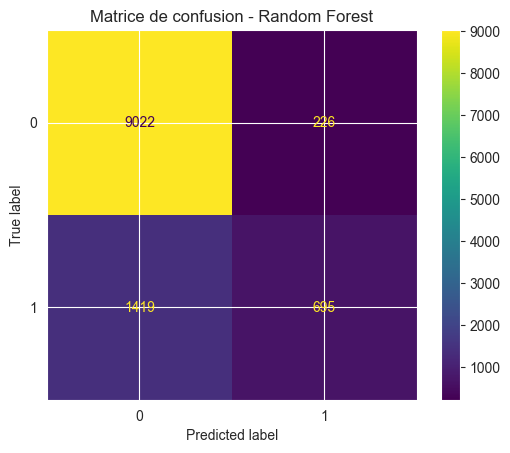


==================== XGBoost ====================


2026/05/08 12:03:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ensemble_word2vec_XGBoost at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/e095174006bd4956b2ec9c2ca2cc3559
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      9248
           1       0.72      0.30      0.43      2114

    accuracy                           0.85     11362
   macro avg       0.79      0.64      0.67     11362
weighted avg       0.83      0.85      0.82     11362



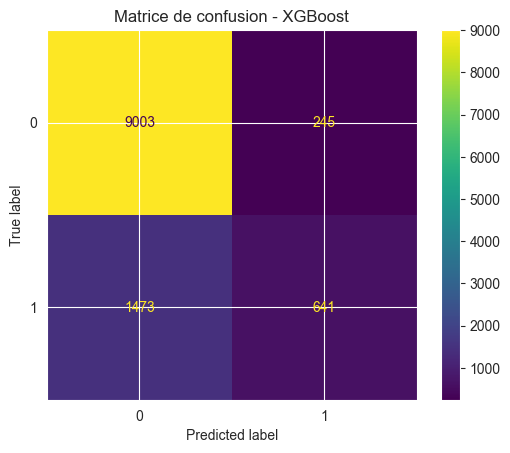


==================== Gradient Boosting ====================


2026/05/08 12:10:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ensemble_word2vec_Gradient Boosting at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/8aa625d2b692430595bd9419306c4a95
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      9248
           1       0.74      0.18      0.29      2114

    accuracy                           0.84     11362
   macro avg       0.79      0.58      0.60     11362
weighted avg       0.82      0.84      0.79     11362



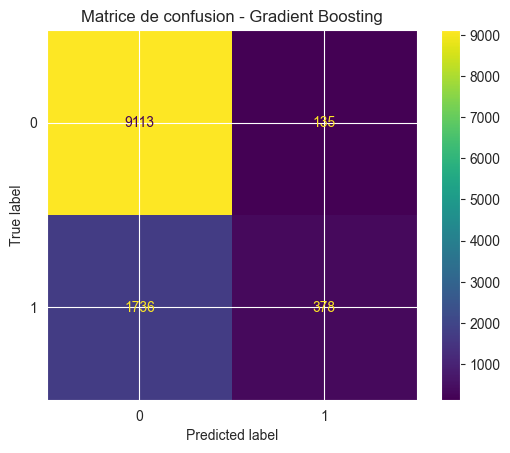


==================== KNN ====================


2026/05/08 12:19:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ensemble_word2vec_KNN at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/eef58bc7b0aa4503a76254733c97b462
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      9248
           1       0.51      0.27      0.35      2114

    accuracy                           0.82     11362
   macro avg       0.68      0.60      0.62     11362
weighted avg       0.79      0.82      0.79     11362



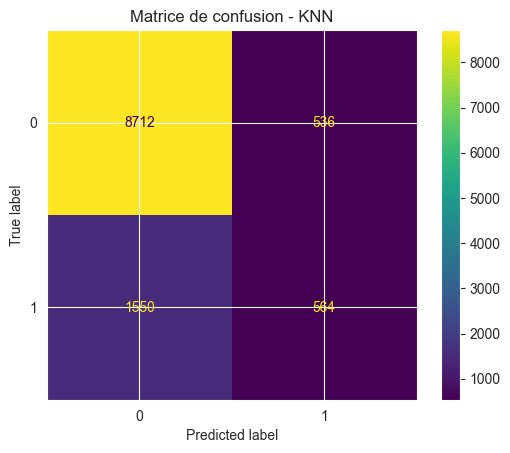


==================== Voting Classifier ====================


2026/05/08 12:26:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ensemble_word2vec_Voting Classifier at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/0d89ffbd83c7460895b09238528bf96d
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      9248
           1       0.75      0.29      0.42      2114

    accuracy                           0.85     11362
   macro avg       0.80      0.63      0.67     11362
weighted avg       0.84      0.85      0.82     11362



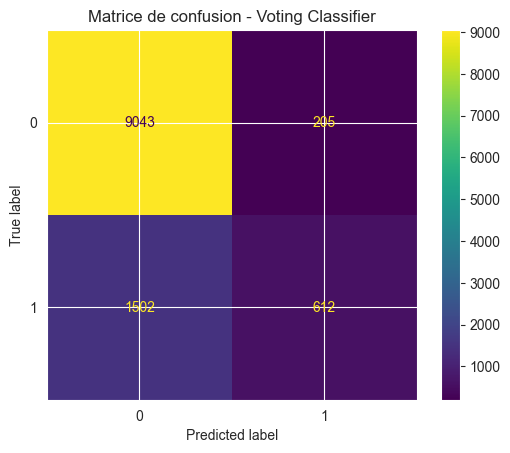

In [50]:
# Validation crois?e
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Liste des r?sultats
resultats_2 = []
fitted_w2v_models = {}

for nom, modele in models_2:
    print(f"\n==================== {nom} ====================")

    pred = cross_val_predict(modele, X, y, cv=cv)

    metrics, fitted_model = log_model_run(
        run_name=f"ensemble_word2vec_{nom}",
        model=modele,
        X_train_full=X,
        y_train_full=y,
        y_true=y,
        y_pred=pred,
        params=modele.get_params(deep=True),
        tags={"model_family": "ensemble", "vectorizer": "word2vec", "tracked_in_mlflow": "true"},
        cv_folds=cv.get_n_splits(),
    )
    fitted_w2v_models[nom] = fitted_model

    print(classification_report(y, pred, zero_division=0))

    ConfusionMatrixDisplay(confusion_matrix(y, pred)).plot()
    plt.title(f"Matrice de confusion - {nom}")
    plt.show()

    resultats_2.append([
        nom,
        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["f2"],
    ])

**Tableau récapitulatif des modèles**

In [52]:
# Tableau r?capitulatif
df_resultats_2 = pd.DataFrame(
    resultats_2,
    columns=["Modèle", "Accuracy", "Précision", "Recall", "F1-score", "F2-score"]
)

colonnes_scores = ["Accuracy", "Précision", "Recall", "F1-score", "F2-score"]
df_resultats_2[colonnes_scores] = (df_resultats_2[colonnes_scores] * 100).round(2)

df_resultats_2 = df_resultats_2.sort_values(by="F2-score", ascending=False).reset_index(drop=True)

df_resultats_2

,Modèle,Accuracy,Précision,Recall,F1-score,F2-score
0,Random Forest,85.52,75.46,32.88,45.80,37.06
1,XGBoost,84.88,72.35,30.32,42.73,34.31
2,Voting Classifier,84.98,74.91,28.95,41.76,33.00
3,KNN,81.64,51.27,26.68,35.10,29.51
4,Gradient Boosting,83.53,73.68,17.88,28.78,21.07


L’analyse des performances montre que les modèles ensemblistes obtiennent des résultats globalement corrects, avec des niveaux d’accuracy relativement proches. Le modèle **Random Forest** apparaît comme le plus performant, avec le meilleur **F1-score** (**45.88 %**) ainsi qu’un bon compromis entre précision et rappel. Il est suivi de près par **XGBoost**, dont les performances restent très similaires.

Le Voting Classifier présente également des résultats satisfaisants, mais sans réellement surpasser les meilleurs modèles individuels. Quant au KNN, il obtient des performances plus modestes, notamment en raison d’un rappel relativement faible. Enfin, **Gradient Boosting** est le modèle le moins performant dans cette configuration, avec un **F1-score** plus faible malgré une précision correcte.

De manière générale, les résultats montrent que les modèles ensemblistes parviennent à bien identifier les tweets non catastrophiques (classe majoritaire), mais rencontrent davantage de difficultés pour détecter correctement les tweets liés aux catastrophes, comme en témoigne le rappel relativement faible observé sur l’ensemble des modèles.

**Optimisation des hyperparamètres**

**1. Random Forest**

In [53]:
# Pipeline Random Forest avec Word2Vec
pipe_rf = Pipeline([
    ("word2vec", Word2VecVectorizer(
        vector_size=100,
        window=5,
        min_count=1,
        workers=1
    )),

    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Grille légère d'hyperparamètres
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

**2. XGBoost**

In [54]:
pipe_xgb = Pipeline([
    ("word2vec", Word2VecVectorizer(vector_size=100, window=5, min_count=1, workers=1)),
    ("model", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

**3. Gradient Boosting**

In [55]:
pipe_gb = Pipeline([
    ("word2vec", Word2VecVectorizer(vector_size=100, window=5, min_count=1, workers=1)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

**4. Voting Classifier**

In [56]:
pipe_voting = Pipeline([
    ("word2vec", Word2VecVectorizer(vector_size=100, window=5, min_count=1, workers=1)),
    ("model", VotingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
            ("xgb", XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric="logloss")),
            ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))
        ],
        voting="hard"
    ))
])

param_grid_voting = {
    "model__voting": ["hard"]
}

**Evaluation et résultats**

In [57]:
# Liste contenant :
# - le nom du mod?le,
# - le pipeline associ?,
# - la grille des hyperparam?tres ? tester
grids = [
    ("Random Forest", pipe_rf, param_grid_rf),
    ("XGBoost", pipe_xgb, param_grid_xgb),
    ("Gradient Boosting", pipe_gb, param_grid_gb),
    ("Voting Classifier", pipe_voting, param_grid_voting),
]

best_models = {}
resultats_grid = []

for nom, pipe, params in grids:
    print(f"\n==================== Optimisation : {nom} ====================")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        # Optimisation basée sur le F2-score pour privilégier la détection des catastrophes (rappel)
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid.fit(X, y)
    best_models[nom] = grid.best_estimator_

    pred_best = cross_val_predict(grid.best_estimator_, X, y, cv=cv)
    cv_results_df = pd.DataFrame(grid.cv_results_)

    metrics, fitted_model = log_model_run(
        run_name=f"optimized_word2vec_{nom}",
        model=grid.best_estimator_,
        X_train_full=X,
        y_train_full=y,
        y_true=y,
        y_pred=pred_best,
        params=grid.best_params_,
        tags={
            "model_family": "optimized_ensemble",
            "vectorizer": "word2vec",
            "optimization_metric": "f2",
            "tracked_in_mlflow": "true",
        },
        cv_folds=cv.get_n_splits(),
        extra_metrics={"best_cv_f2": grid.best_score_},
        extra_artifacts={
            "best_params.json": grid.best_params_,
            "grid_search_cv_results.csv": cv_results_df,
        },
    )

    resultats_grid.append([
        nom,
        grid.best_score_,
        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["f2"],
        grid.best_params_,
    ])

    print("Meilleur F2-score GridSearch :", round(grid.best_score_ * 100, 2), "%")
    print("F2-score CV du meilleur mod?le :", round(metrics["f2"] * 100, 2), "%")
    print("Meilleurs param?tres :", grid.best_params_)


==================== Optimisation : Random Forest ====================
Fitting 5 folds for each of 72 candidates, totalling 360 fits


2026/05/08 13:22:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run optimized_word2vec_Random Forest at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/3b7522c6daf847a7bc9e3f5ddeae74ba
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
Meilleur F2-score GridSearch : 37.05 %
F2-score CV du meilleur mod?le : 37.06 %
Meilleurs param?tres : {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

==================== Optimisation : XGBoost ====================
Fitting 5 folds for each of 16 candidates, totalling 80 fits


2026/05/08 13:39:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run optimized_word2vec_XGBoost at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/a95c5fd0c26d45d9a01bf85e092c04da
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
Meilleur F2-score GridSearch : 39.16 %
F2-score CV du meilleur mod?le : 39.57 %
Meilleurs param?tres : {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}

==================== Optimisation : Gradient Boosting ====================
Fitting 5 folds for each of 8 candidates, totalling 40 fits


2026/05/08 14:33:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run optimized_word2vec_Gradient Boosting at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/b8c37a7f60404528927237253be58ac9
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
Meilleur F2-score GridSearch : 36.28 %
F2-score CV du meilleur mod?le : 36.29 %
Meilleurs param?tres : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

==================== Optimisation : Voting Classifier ====================
Fitting 5 folds for each of 1 candidates, totalling 5 fits


2026/05/08 14:55:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run optimized_word2vec_Voting Classifier at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6/runs/c63297ddae04424898c78faa7ef0058f
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/6
Meilleur F2-score GridSearch : 35.82 %
F2-score CV du meilleur mod?le : 35.82 %
Meilleurs param?tres : {'model__voting': 'hard'}


**Récapitulatif des résultats**

In [58]:
# Transformation des r?sultats en DataFrame
resultats_grid = pd.DataFrame(
    resultats_grid,
    columns=[
        "Mod?le",
        "Meilleur F2-score GridSearch",
        "Accuracy",
        "Pr?cision",
        "Recall",
        "F1-score",
        "F2-score",
        "Meilleurs param?tres",
    ]
)

colonnes_scores = ["Meilleur F2-score GridSearch", "Accuracy", "Pr?cision", "Recall", "F1-score", "F2-score"]
resultats_grid[colonnes_scores] = (resultats_grid[colonnes_scores] * 100).round(2)

resultats_grid = resultats_grid.sort_values(by="F2-score", ascending=False).reset_index(drop=True)

resultats_grid

,Mod?le,Meilleur F2-score GridSearch,Accuracy,Pr?cision,Recall,F1-score,F2-score,Meilleurs param?tres
0,XGBoost,39.16,85.60,73.39,35.48,47.83,39.57,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,Random Forest,37.05,85.52,75.46,32.88,45.80,37.06,"{'model__max_depth': None, 'model__max_feature..."
2,Gradient Boosting,36.28,85.02,71.59,32.31,44.52,36.29,"{'model__learning_rate': 0.1, 'model__max_dept..."
3,Voting Classifier,35.82,85.83,80.51,31.46,45.24,35.82,{'model__voting': 'hard'}


**Récupération et sauvegarde du meilleur modèle**

In [ ]:
# S?lection automatique du meilleur mod?le selon le F2-score
best_model_name = resultats_grid.sort_values(by="F2-score", ascending=False).iloc[0]["Mod?le"]

best_model = best_models[best_model_name]

joblib.dump(best_model, "best_model_ensemble.pkl")

print("Meilleur modèle selon F2-score :", best_model_name)
print("Mod?le sauvegard? sous : best_model_ensemble.pkl")